## Import thư viện

In [10]:
from vnstock import *
import pandas as pd
import time
import matplotlib.pyplot as plt

## Crawl Mã chứng khoán Bán lẻ

In [114]:
# Mã Bán lẻ
symbols = ["CMV","COM","CPH","MWG","HTM","IED","ICL","TOP","UNM","HTT","PSD","THS","DGW","VT1","FRT","PNG","PET","SAS","TV6","AGX","FHN","DHT","BTT","T12","SAD","DKC","LBC","TLS","CEN","AFX","TH1","GEM","CGL","PIT","AST","HFX","SBV","KGM"]

In [115]:
stock = Vnstock().stock(symbol='CMV', source='VCI')

In [116]:
df_total = pd.DataFrame()

for symbol in symbols:
    try:
        df = stock.quote.history(symbol=symbol, start='2020-01-01', end='2024-12-31', interval='1D')
        df['symbol'] = symbol
        df_total = pd.concat([df_total, df], ignore_index=True)
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:

        print(f"Unexpected error for symbol {symbol}: {e}")
    time.sleep(1)

Unexpected error for symbol IED: RetryError[<Future at 0x1bd7dd00a50 state=finished raised ValueError>]
Unexpected error for symbol ICL: RetryError[<Future at 0x1bd7def58d0 state=finished raised ValueError>]
Unexpected error for symbol UNM: RetryError[<Future at 0x1bd056eed50 state=finished raised ValueError>]
Unexpected error for symbol VT1: RetryError[<Future at 0x1bd7dbb6fd0 state=finished raised ValueError>]
Unexpected error for symbol T12: RetryError[<Future at 0x1bd7e25ead0 state=finished raised ValueError>]
Unexpected error for symbol SAD: RetryError[<Future at 0x1bd020695d0 state=finished raised ValueError>]
Unexpected error for symbol TLS: RetryError[<Future at 0x1bd7f011cd0 state=finished raised ValueError>]
Unexpected error for symbol GEM: RetryError[<Future at 0x1bd03477950 state=finished raised ValueError>]


### **Các Mã chứng khoán bị lỗi : IED, ICL, UNM, VT1, T12, SAD, TLS, GEM**

In [117]:
df_total.to_csv("Ban_Le.csv", index=False)

## Crawl VNINDEX

In [118]:
df_vnindex = stock.quote.history(symbol='VNINDEX', start='2020-01-01', end='2024-12-31', interval='1D')

In [119]:
df_vnindex.to_csv("VNINDEX.csv", index=False)

## Giải thích data

In [3]:
stock = pd.read_csv("BT1/Ban_Le.csv")
vnindex = pd.read_csv("BT1/VNINDEX.csv")

In [126]:
# Info của stock
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34751 entries, 0 to 34750
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    34751 non-null  object 
 1   open    34751 non-null  float64
 2   high    34751 non-null  float64
 3   low     34751 non-null  float64
 4   close   34751 non-null  float64
 5   volume  34751 non-null  int64  
 6   symbol  34751 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 1.9+ MB


***Giải thích ý nghĩa các field***

- **time**: Ngày giao dịch
- **open**: Mức giá đầu tiên khi thị trường mở cửa trong ngày
- **high**: Mức giá cao nhất của cổ phiếu trong ngày
- **low**: Mức giá thấp nhất của cổ phiếu trong ngày
- **close**: Mức giá cuối cùng khi thị trường đóng cửa trong ngày
- **volumn**: Khối lượng giao dịch (tổng cổ phiếu giao dịch trong ngày)
- **symbol**: Mã chứng khoán

In [131]:
# Info của VN-Index
vnindex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    1250 non-null   object 
 1   open    1250 non-null   float64
 2   high    1250 non-null   float64
 3   low     1250 non-null   float64
 4   close   1250 non-null   float64
 5   volume  1250 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 58.7+ KB


***Giải thích vnindex:*** 

VN-Index tương tự nhưng khác là sẽ cộng hết của tất cả các mã chứng khoán niêm yết trên sàn HOSE.

In [5]:
stock['time'] = pd.to_datetime(stock['time'])
vnindex['time'] = pd.to_datetime(vnindex['time'])

In [6]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34751 entries, 0 to 34750
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    34751 non-null  datetime64[ns]
 1   open    34751 non-null  float64       
 2   high    34751 non-null  float64       
 3   low     34751 non-null  float64       
 4   close   34751 non-null  float64       
 5   volume  34751 non-null  int64         
 6   symbol  34751 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 1.9+ MB


In [187]:
stock.head(5)

,time,open,high,low,close,volume,symbol
0,2020-01-02,10.44,10.44,10.44,10.44,0,CMV
1,2020-01-03,10.44,10.44,10.44,10.44,0,CMV
2,2020-01-06,10.44,10.44,10.44,10.44,0,CMV
3,2020-01-07,10.44,10.44,10.44,10.44,0,CMV
4,2020-01-08,10.44,10.44,10.44,10.44,0,CMV


In [188]:
vnindex.head(5)

,time,open,high,low,close,volume,value
0,2020-01-02,960.26,966.67,959.67,966.67,131523160,31.045755
1,2020-01-03,968.72,970.88,965.14,965.14,149202550,31.045755
2,2020-01-06,962.79,963.20,955.59,955.79,140978550,31.045755
3,2020-01-07,955.39,959.46,953.19,958.88,130272030,31.045755
4,2020-01-08,954.13,955.84,945.28,948.98,179374340,31.045755


## Trực quan hóa chỉ số Index tăng theo từng ngày so với Vnindex của từng mã chứng khoán trong vòng 5 năm

In [7]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0]    

In [8]:
from matplotlib import dates

def show_plt(symbol):
  time_stock = stock[stock['symbol'] == symbol]['time']
  value_stock = stock[stock['symbol'] == symbol]['close']

  time_vnindex = vnindex['time']
  value_vnindex = vnindex['close']

  plt.figure(figsize=(10, 6))
  plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
  plt.plot(time_vnindex, growth_index_per_day(value_vnindex), color='red', label="VN-INDEX")

  plt.gca().xaxis.set_major_locator(dates.MonthLocator(interval=3))
  plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%b %Y'))
  plt.gcf().autofmt_xdate()

  plt.grid(True)
  plt.legend(loc='upper left')  # Đảm bảo legend hiển thị
  # Cố định scale trục tung
  plt.ylim(-150, 1500)  # Điều chỉnh tùy theo độ biến động bạn muốn theo dõi

  plt.title(f"{symbol} and VN-INDEX", fontsize=16)

  plt.show()

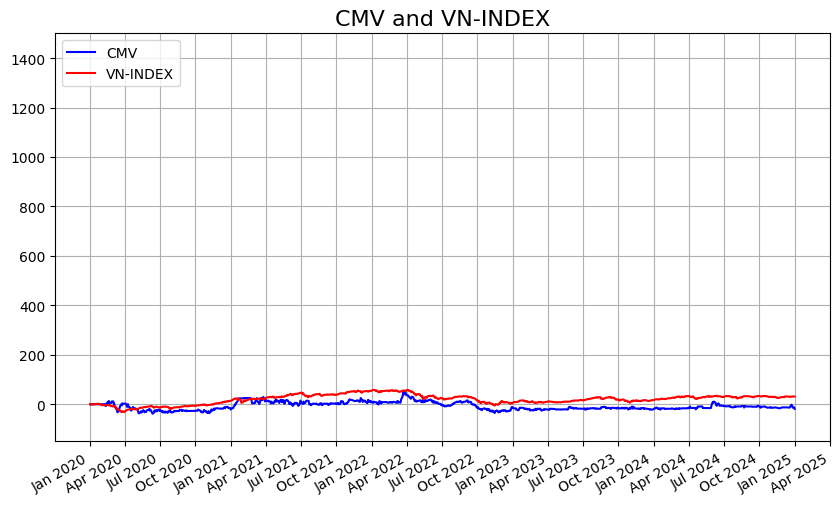

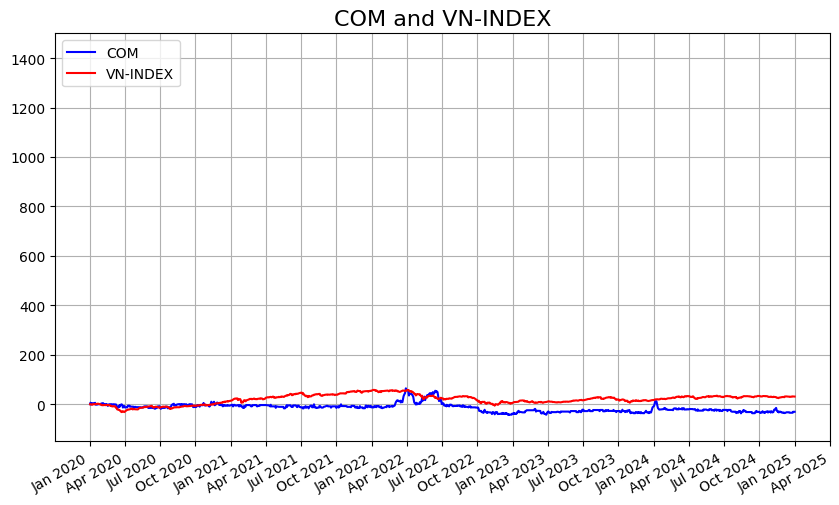

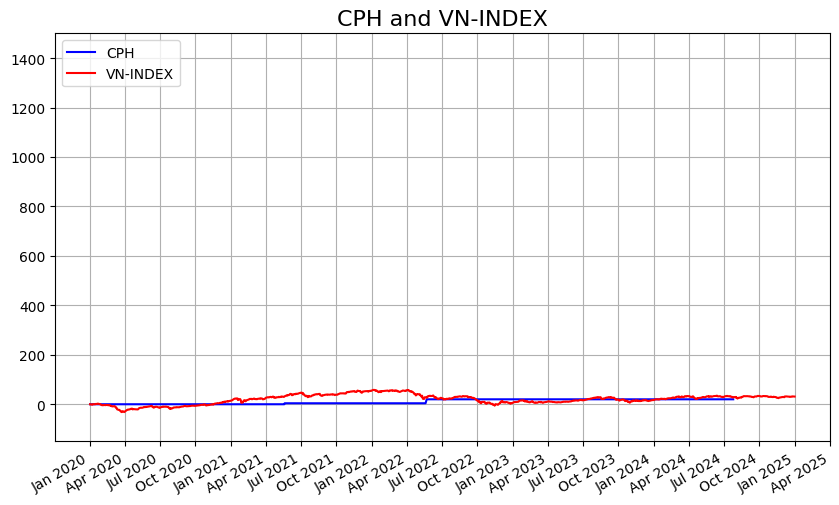

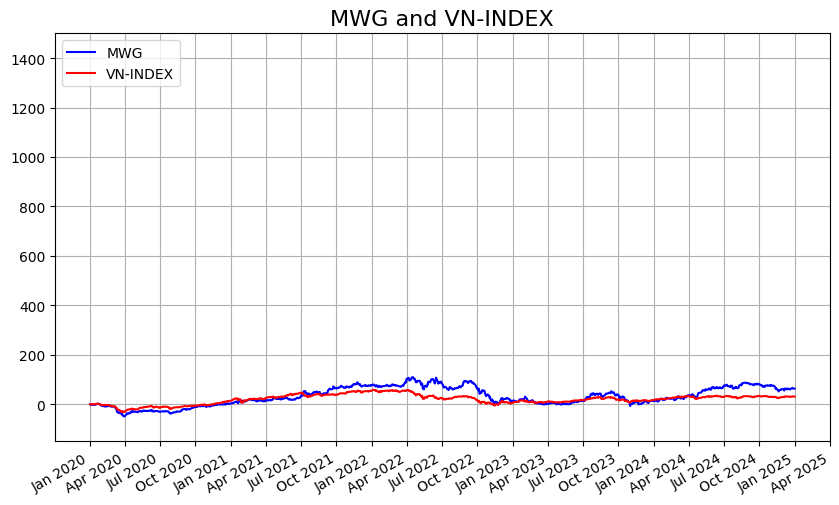

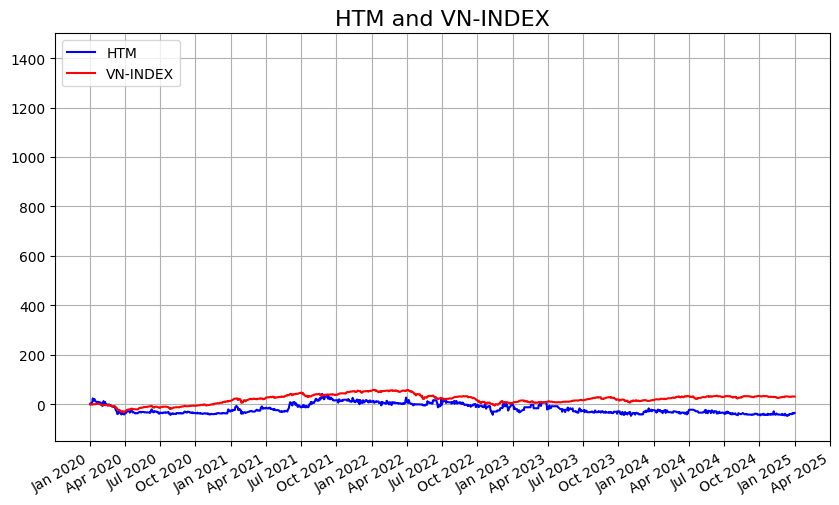

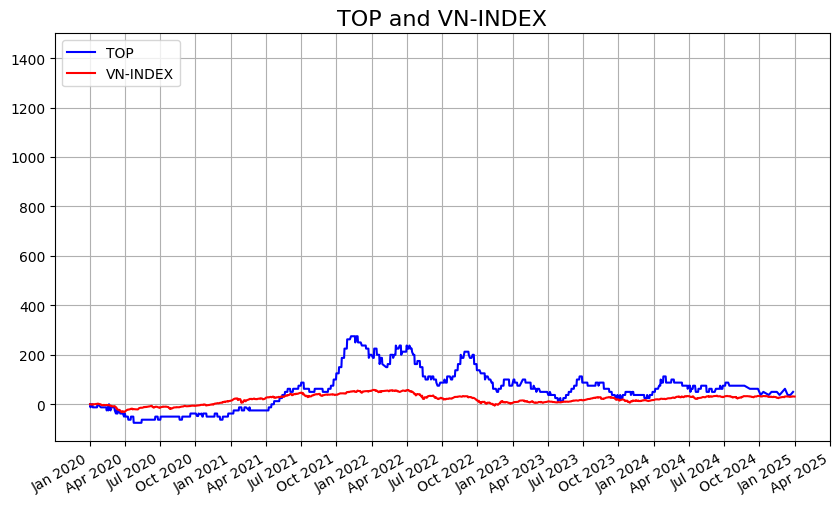

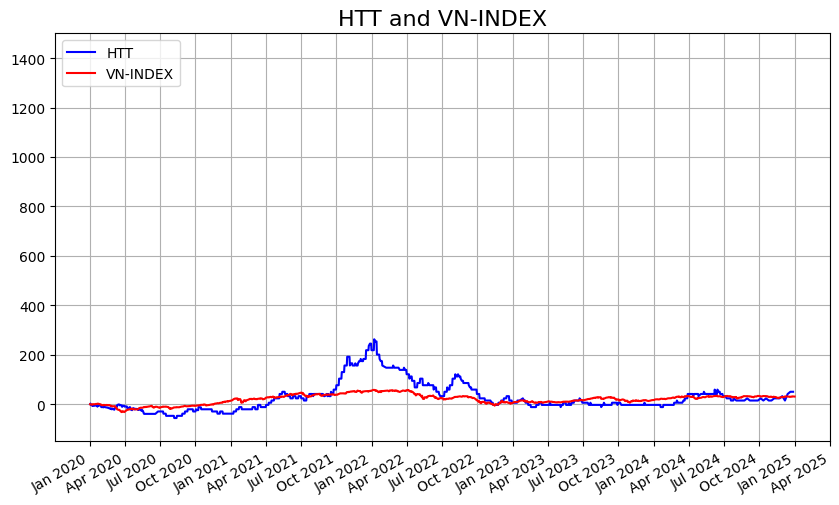

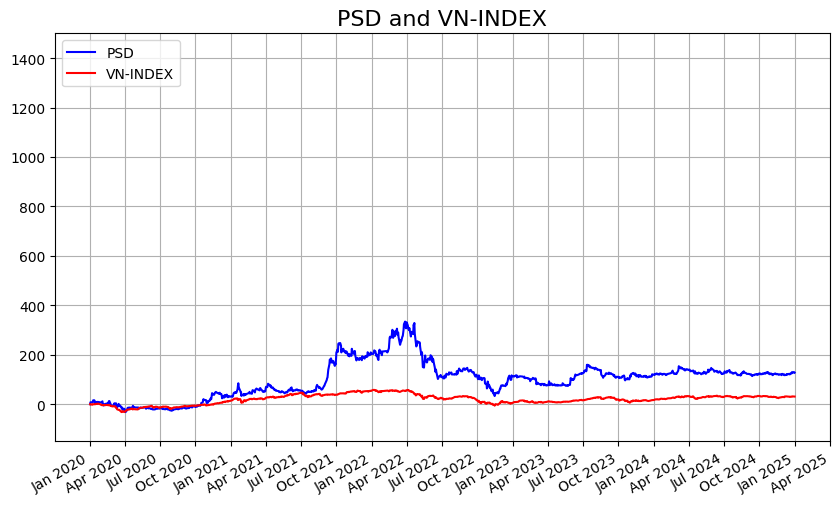

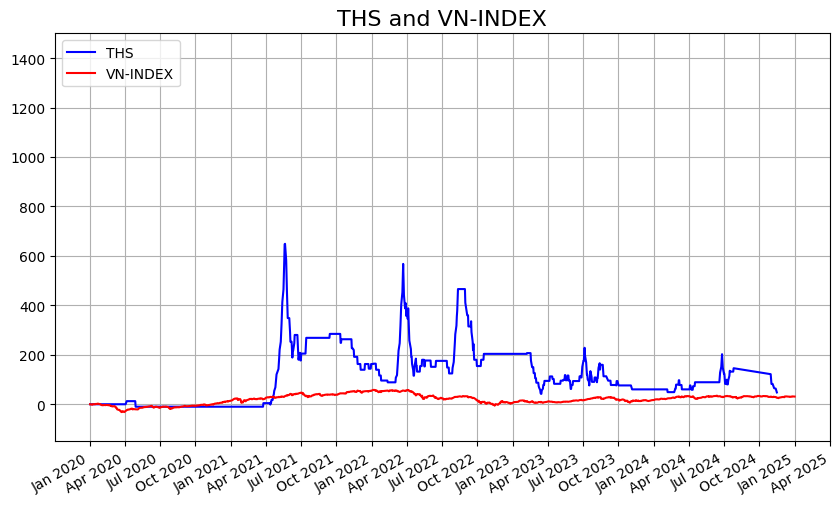

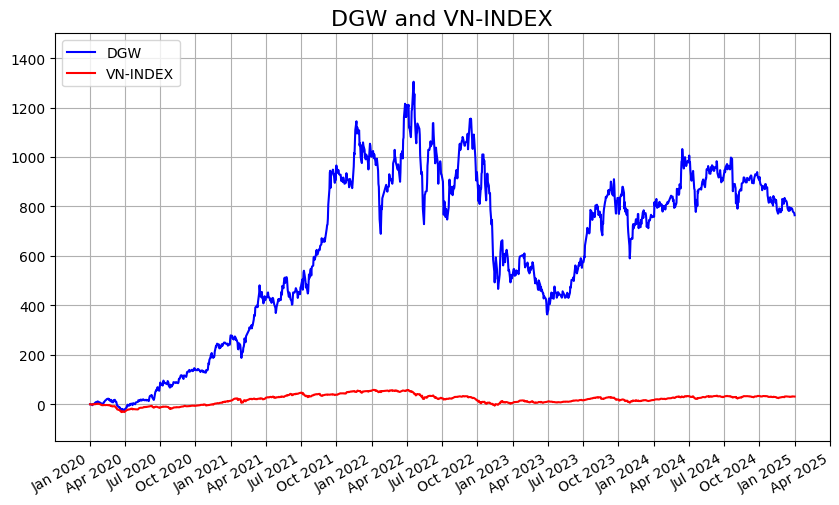

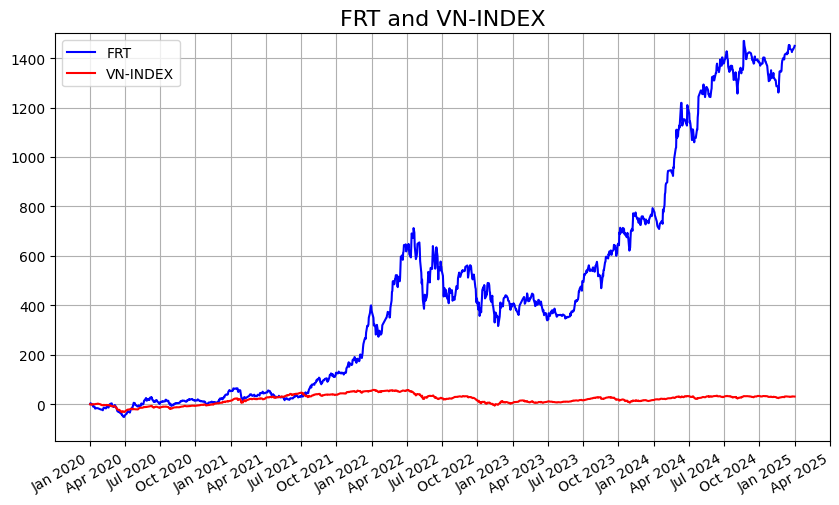

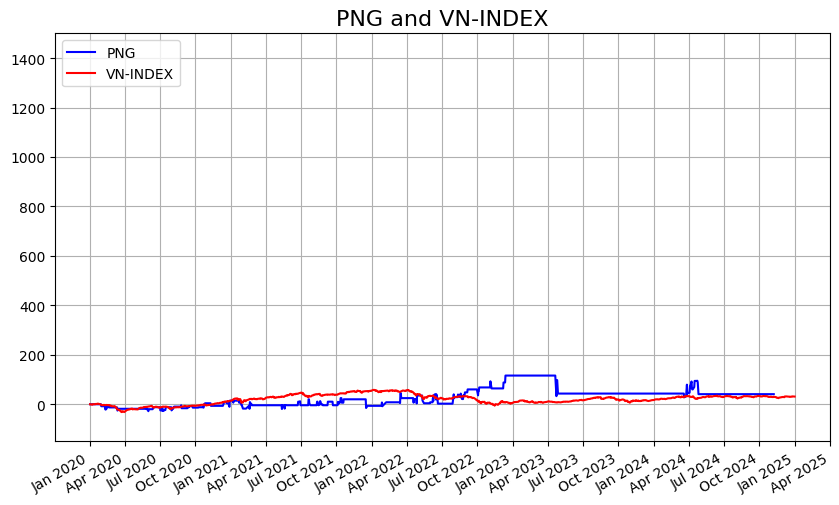

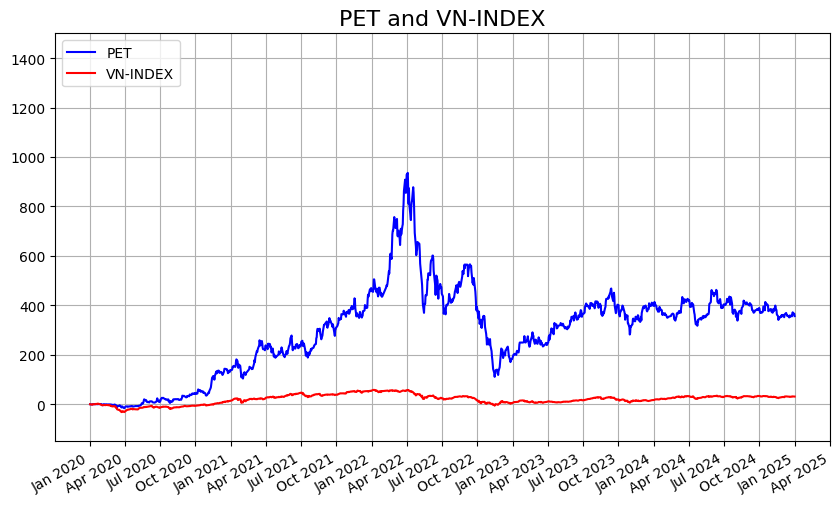

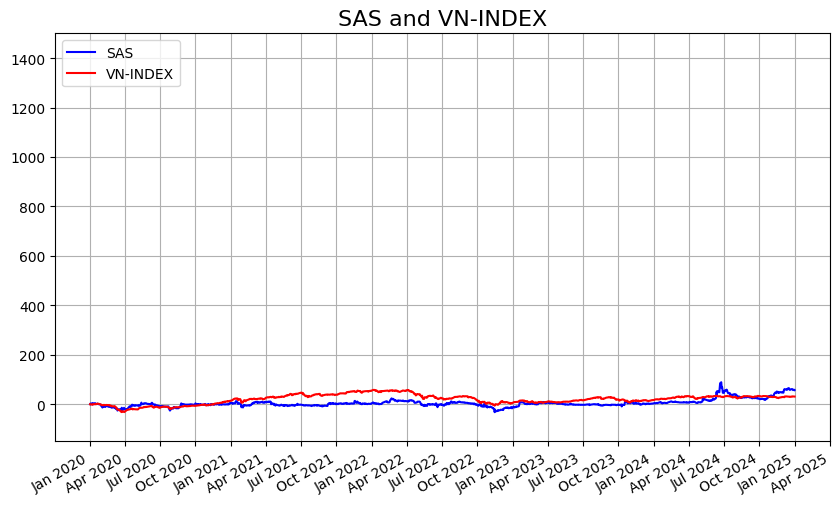

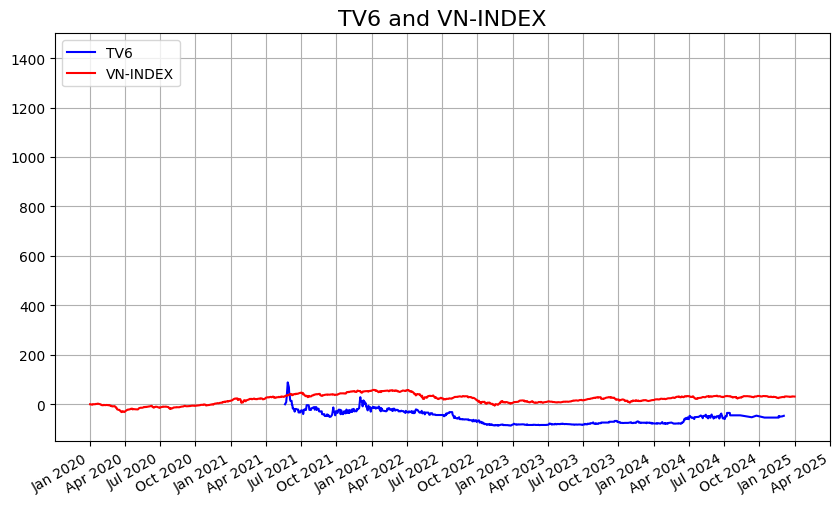

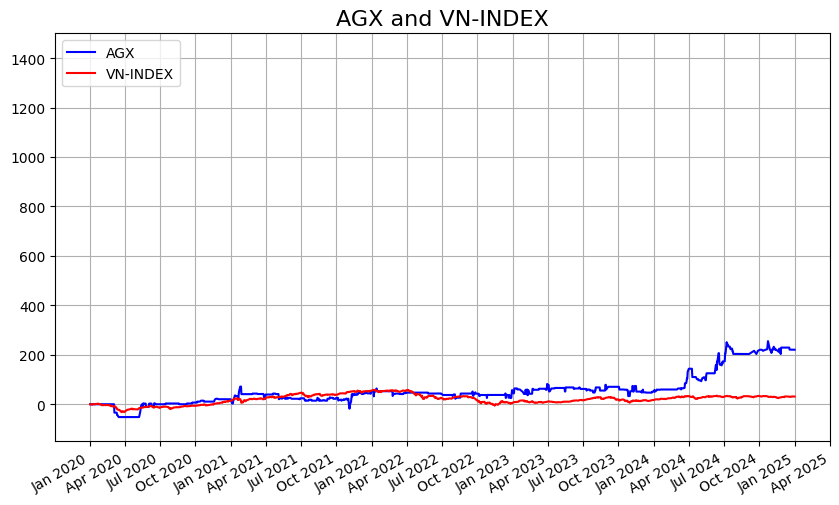

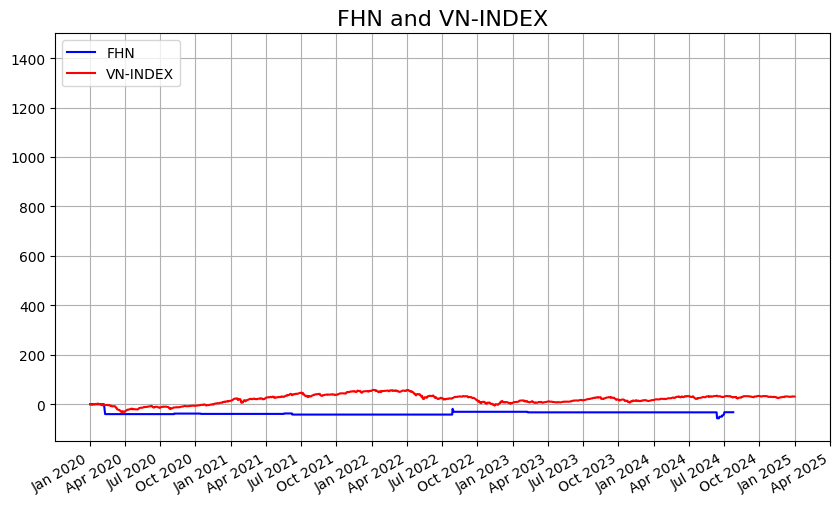

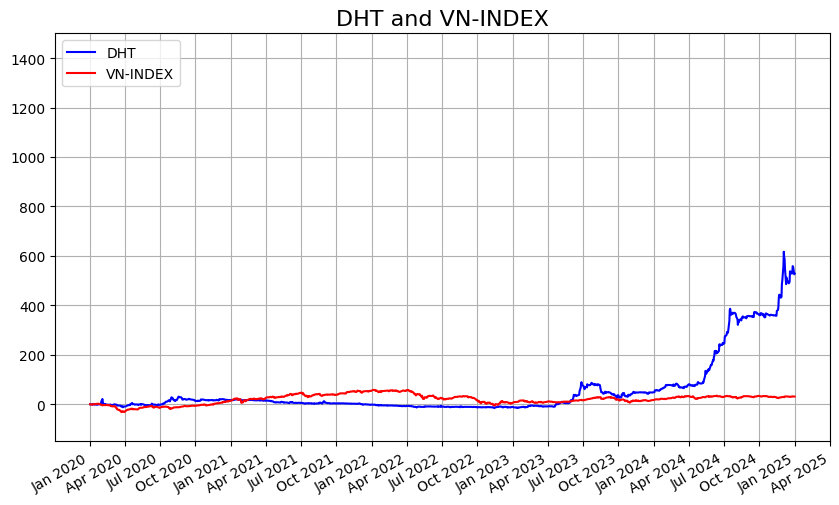

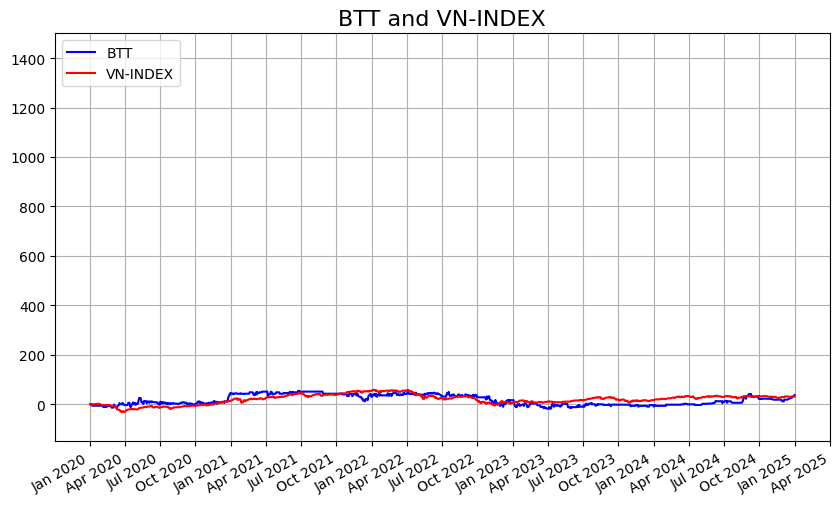

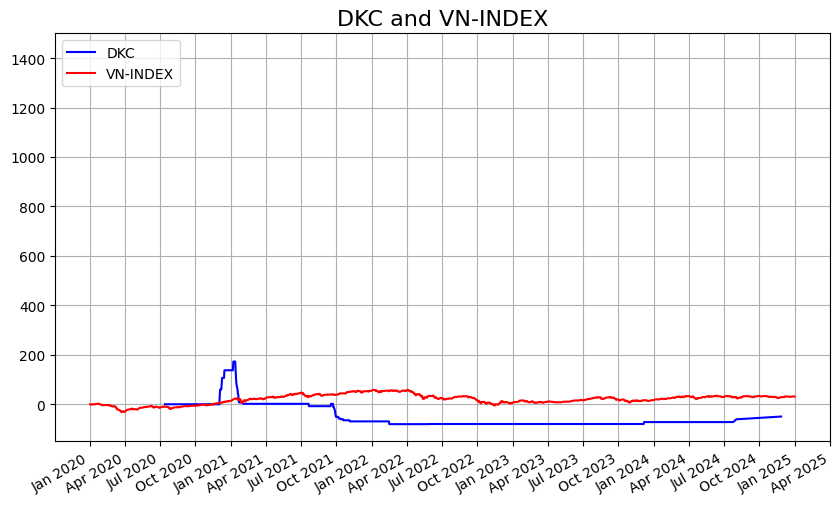

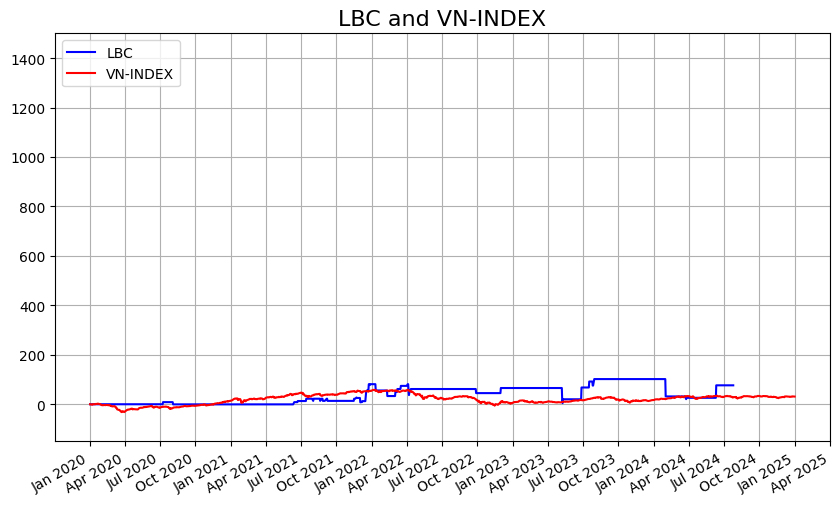

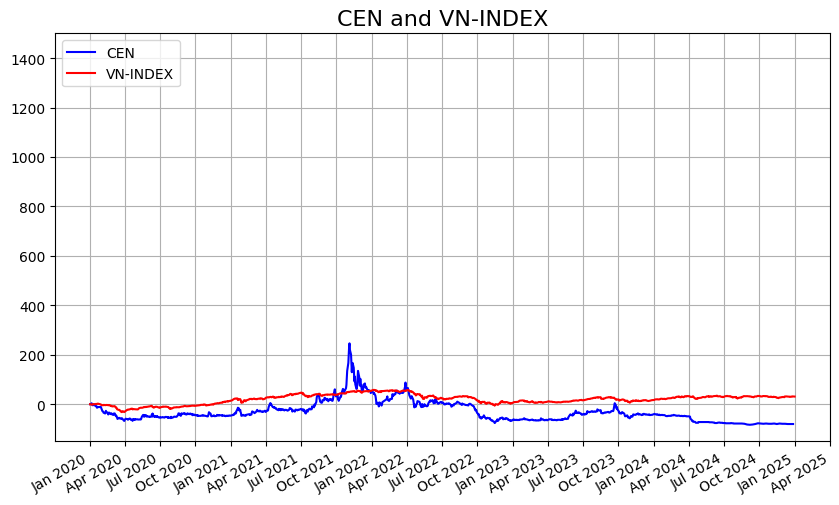

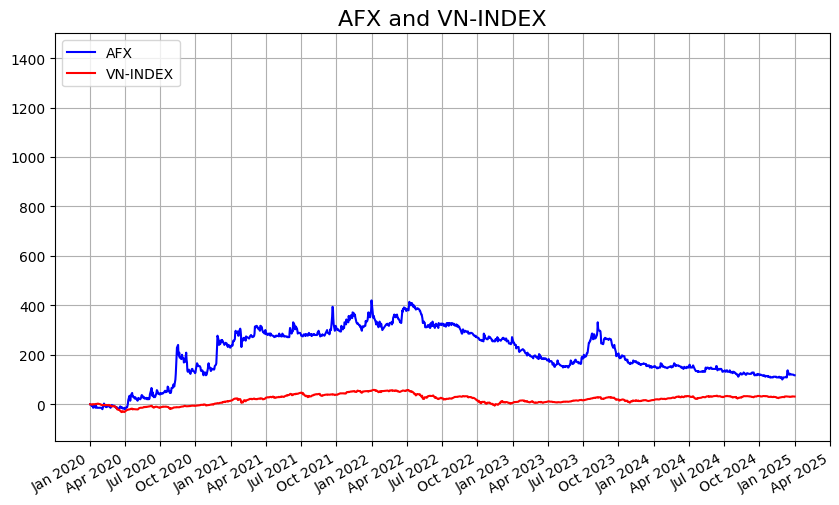

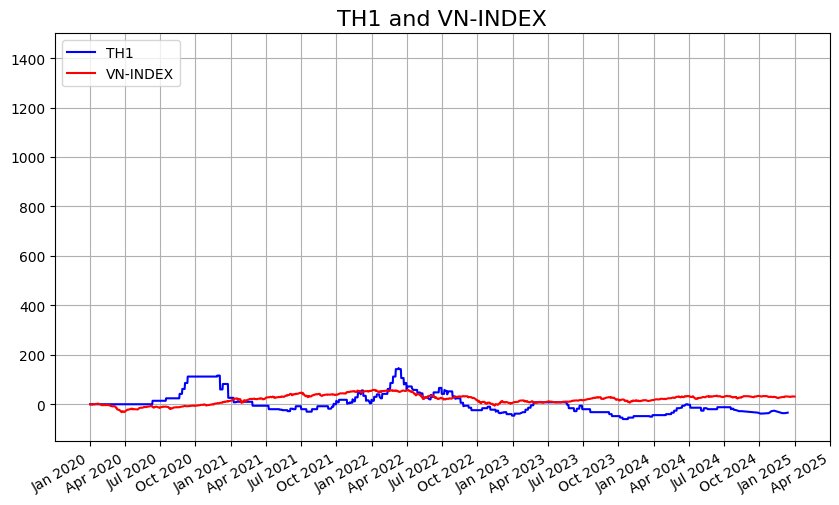

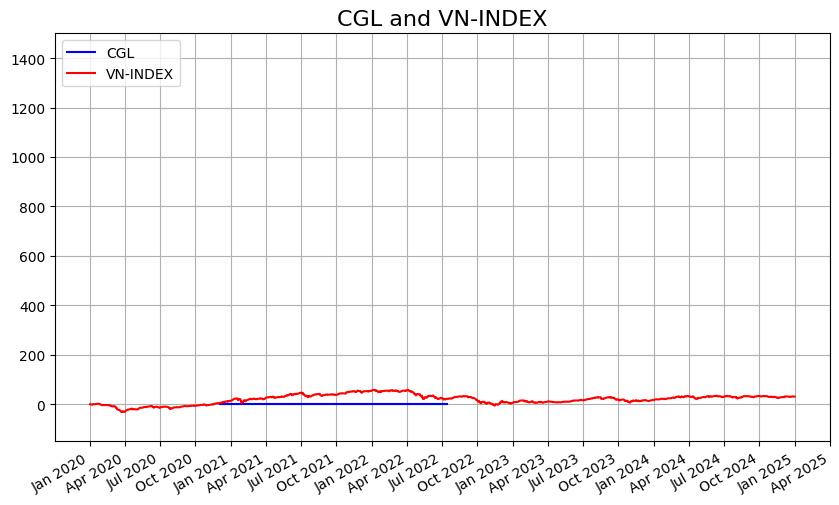

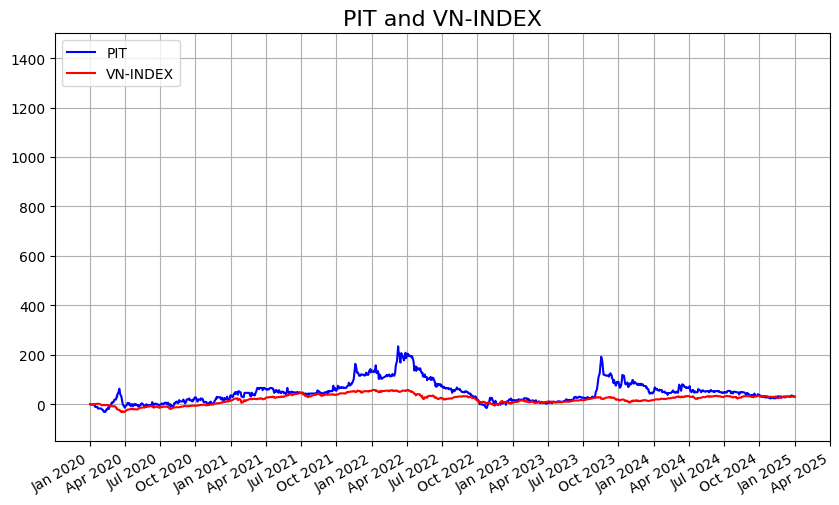

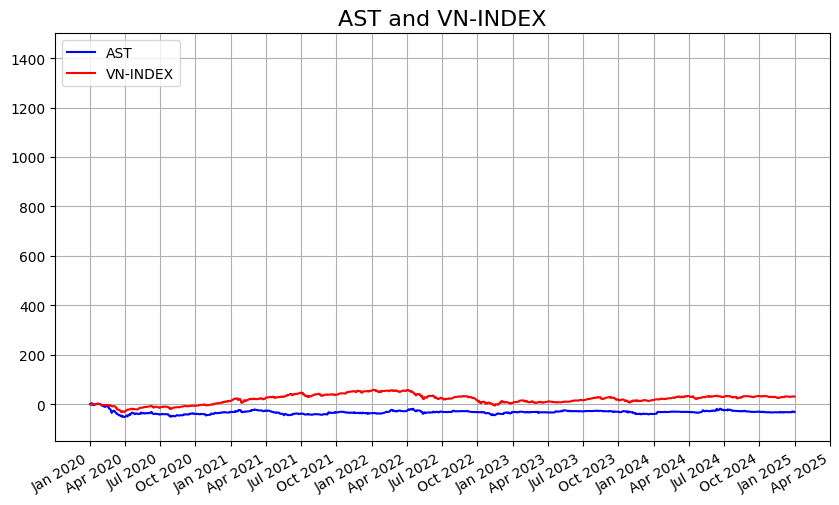

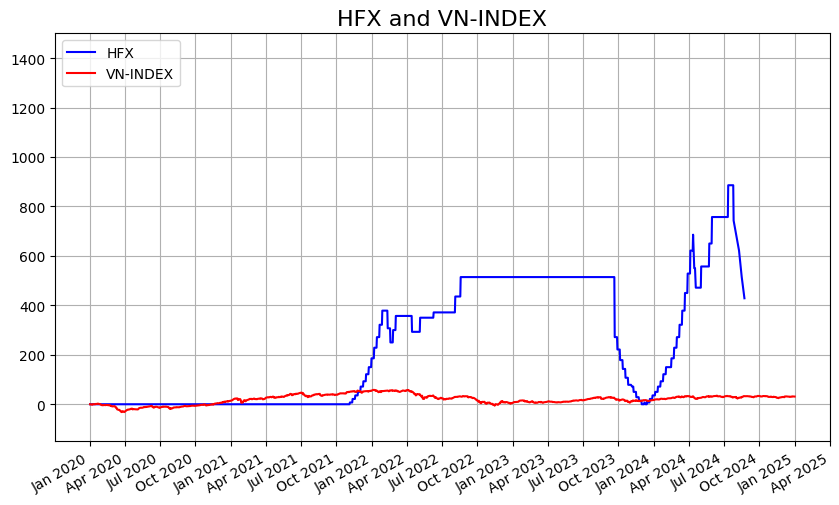

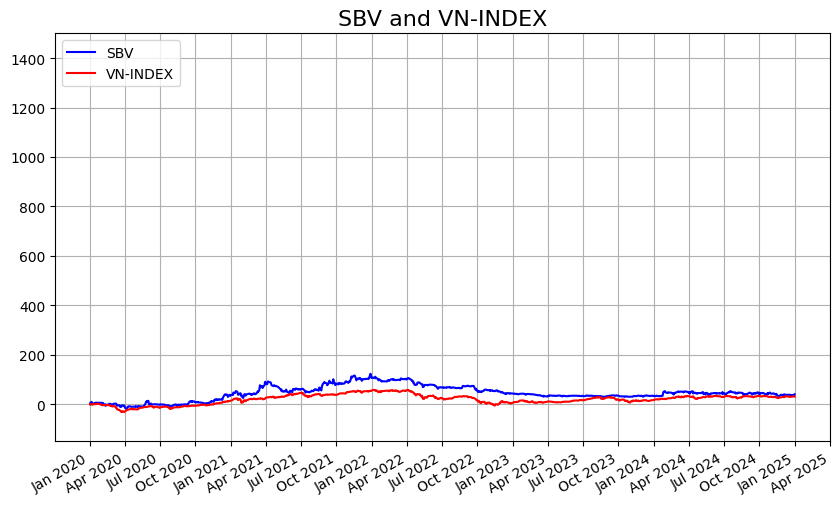

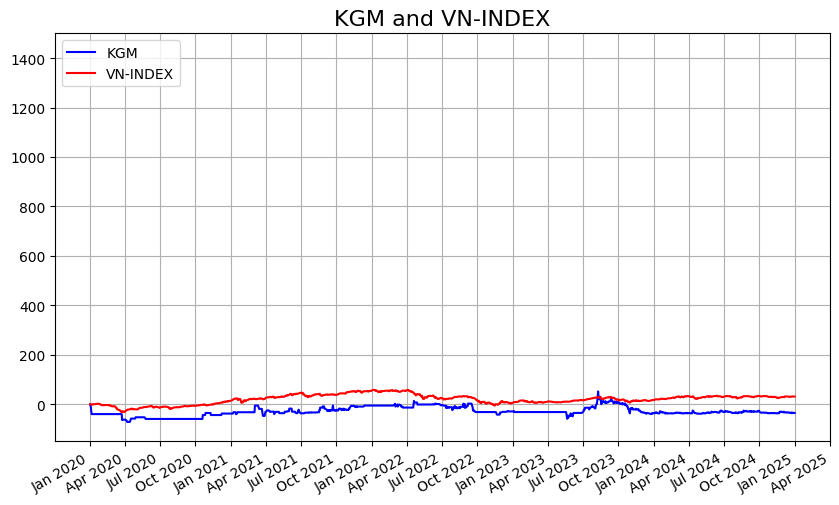

In [9]:
for symbol in stock['symbol'].unique():
  show_plt(symbol)

## Tính chỉ số tăng của từng mã so với VN-INDEX trong vòng 5 năm

In [164]:
def growth_index_5_years(df):
    close_last = df.loc[df['time'].idxmax(), 'close']
    close_first = df.loc[df['time'].idxmin(), 'close']
    growth_value = (close_last - close_first) * 100 / close_first
    return growth_value

In [165]:
vnindex_item = {}
vnindex_item['symbol'] = 'VNINDEX'
vnindex_item['value'] = growth_index_5_years(vnindex)

symbol_stocks = []
for symbol in stock['symbol'].unique():
    item = {}
    item['symbol'] = symbol
    df_symbol = stock[(stock['symbol'] == symbol)]
    item['value'] = growth_index_5_years(df_symbol)
    symbol_stocks.append(item)

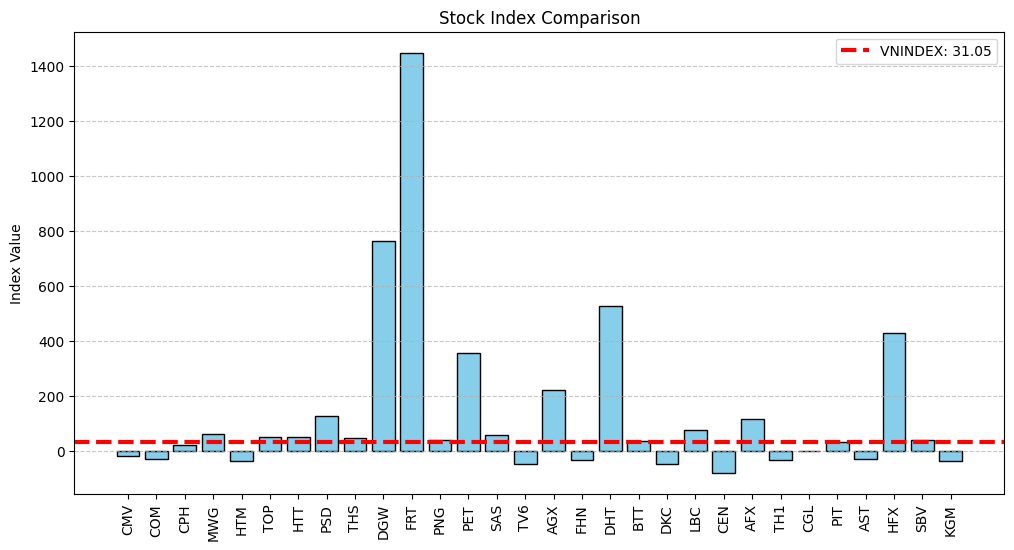

In [173]:
# Trực quan hóa 
vnindex_value = vnindex_item['value']

symbols = [symbol_stock['symbol'] for symbol_stock in symbol_stocks]
values = [symbol_stock['value'] for symbol_stock in symbol_stocks]

plt.figure(figsize=(12, 6))
plt.bar(symbols, values, color='skyblue', edgecolor='black')

plt.axhline(y=vnindex_value, color="red", linestyle="--", linewidth=3, label=f"VNINDEX: {vnindex_value:.2f}")

plt.xticks(rotation=90)
plt.ylabel("Index Value")
plt.title("Stock Index Comparison")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Liệt kê các mã chứng khoán có Index cao hơn Vnindex

In [189]:
growth_vnindex = pd.DataFrame([vnindex_item])
threshold = growth_vnindex['value'].iloc[0]

In [190]:
growth_stock = pd.DataFrame(symbol_stocks)
growth_stock.head(10)

,symbol,value
0,CMV,-18.582375
1,COM,-30.537581
2,CPH,20.000000
3,MWG,62.970879
4,HTM,-35.559461
5,TOP,50.000000
6,HTT,50.442478
7,PSD,128.014842
8,THS,47.766323
9,DGW,764.516129


In [192]:
df = growth_stock[growth_stock['value'] > threshold]
df['symbol'].unique()

array(['MWG', 'TOP', 'HTT', 'PSD', 'THS', 'DGW', 'FRT', 'PNG', 'PET',
       'SAS', 'AGX', 'DHT', 'BTT', 'LBC', 'AFX', 'HFX', 'SBV'],
      dtype=object)

### Các mã chứng khoán sau: MWG, TOP, HTT, PSD, THS, DGW, FRT, PNG, PET, SAS, AGX, DHT, BTT, LBC, AFX, HFX, SBV có Index cao hơn chỉ số Vnindex